In [1]:
import numpy as np
import pandas as pd # 
import matplotlib.pyplot as plt

# 데이터 전처리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Model 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

In [2]:
# ImageDataGenerator를 생성해서 사용해 보아요!
# 이미지로부터 픽셀정보를 생성

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator    # 케라스가 가진 전처리기능 중 이미지를 전처리하는
import matplotlib.pyplot as plt

train_dir = 'data/cat_dog_small/train'
validation_dir = 'data/cat_dog_small/validation'

# ImageDataGenerator 생성
train_datagen = ImageDataGenerator(rescale=1/255,
                                  rotation_range=20,  # 회전하는 범위를 정해주는거고 그 범위안에서 랜덤으로 회전값을 정함 (범위는 약간만 수정하는거라 범위를 크게 잡는건 No)
                                  width_shift_range=0.1,  # 범위에서 좌우(왼쪽오른쪽)로 10%내 범위에서 이동
                                  height_shift_range=0.1,  # 범위에서 위아래
                                  zoom_range=0.2,   # 확대
                                  horizontal_flip=True,  # 좌우 뒤집고
                                  vertical_flip=True,   # 상하 뒤집고
                                  shear_range=0.1,
                                  fill_mode='nearest')    
validation_datagen = ImageDataGenerator(rescale=1/255) 

# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir, 
    classes=['cats','dogs'],  
    target_size=(150,150),    
    batch_size=20,     
    class_mode='binary'  
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,  
    classes=['cats','dogs'], 
    target_size=(150,150),    
    batch_size=20,     
    class_mode='binary'  
)

for x_data, t_data in train_generator:
    print(f'x_data의 shape : {x_data.shape}')   # (20, 150, 150, 3)
    print(f't_data의 shape : {t_data.shape}')   # (20,)
    break;

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
x_data의 shape : (20, 150, 150, 3)
t_data의 shape : (20,)


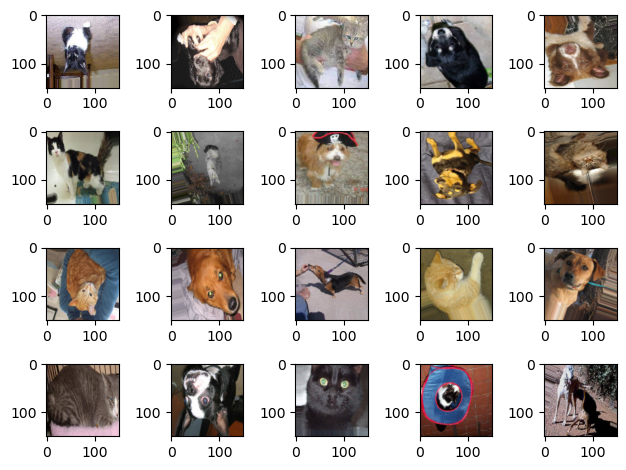

In [3]:
# generator를 이용해서 20장의 이미지를 출력해보세요 (4행 5열)

fig = plt.figure()
axs = []

for i in range(20):
    axs.append(fig.add_subplot(4,5,i+1))

for x_data, t_data in train_generator:
    # print(f'x_data의 shape : {x_data.shape}')   # (20, 150, 150, 3)
    for idx, img_data in enumerate(x_data):
        axs[idx].imshow(img_data)
    break;

plt.tight_layout()
plt.show()

In [4]:
model = Sequential()
model.add(Conv2D(filters=32,
                 kernel_size=(3,3),
                 activation='relu',
                 strides=(1,1),
                 padding='SAME',
                 input_shape=(150,150,3)
))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,
                 kernel_size=(3,3),
                 activation='relu',
                 strides=(1,1),
                 padding='SAME'
))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=125,
                 kernel_size=(3,3),
                 activation='relu',
                 strides=(1,1),
                 padding='SAME'
))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=256,
                 kernel_size=(3,3),
                 activation='relu',
                 strides=(1,1),
                 padding='SAME'
))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dropout(rate=0.5))

model.add(Dense(units=128))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(units=1,
               activation='sigmoid'))

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 75, 75, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 37, 37, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 37, 37, 125)       72125     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 18, 18, 125)       0

In [5]:
model.compile(optimizer=RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [6]:
# 학습 진행
history = model.fit(train_generator,  
                    steps_per_epoch=100, 
                    epochs=30,
                    validation_data=validation_generator,
                    validation_steps=50)

Epoch 1/30
100/100 [==============================] - 12s 91ms/step - loss: 0.7507 - accuracy: 0.5365 - val_loss: 0.6888 - val_accuracy: 0.5020
Epoch 2/30
100/100 [==============================] - 8s 81ms/step - loss: 0.7002 - accuracy: 0.5975 - val_loss: 0.6938 - val_accuracy: 0.5090
Epoch 3/30
100/100 [==============================] - 8s 81ms/step - loss: 0.6949 - accuracy: 0.6045 - val_loss: 0.6683 - val_accuracy: 0.5290
Epoch 4/30
100/100 [==============================] - 8s 80ms/step - loss: 0.6679 - accuracy: 0.6260 - val_loss: 0.6715 - val_accuracy: 0.5650
Epoch 5/30
100/100 [==============================] - 8s 80ms/step - loss: 0.6410 - accuracy: 0.6260 - val_loss: 0.6293 - val_accuracy: 0.6360
Epoch 6/30
100/100 [==============================] - 8s 80ms/step - loss: 0.6035 - accuracy: 0.6730 - val_loss: 0.6013 - val_accuracy: 0.6720
Epoch 7/30
100/100 [==============================] - 8s 80ms/step - loss: 0.6106 - accuracy: 0.6615 - val_loss: 0.5957 - val_accuracy: 0.658

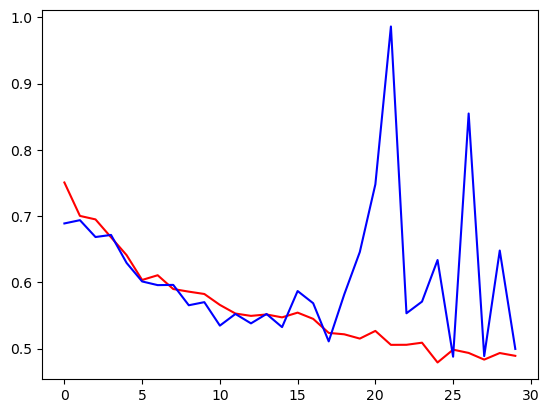

In [8]:
# 그래프로 loss를 살펴보자. 학습을 할수록 로스값이 떨어져야 좋은 성능이다~
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(train_loss, color='r')
plt.plot(val_loss, color='b')
plt.show()

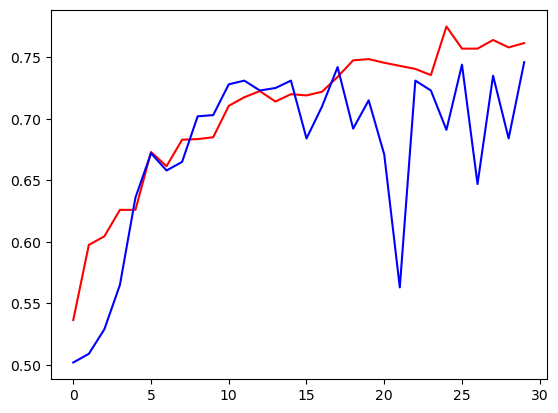

In [9]:
# 그래프로 accuracy를 살펴보자. 학습을 할수록 로스값이 떨어져야 좋은 성능이다~
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.plot(train_accuracy, color='r')
plt.plot(val_accuracy, color='b')
plt.show()

In [10]:
# 이미지 부족으로 인해 모델의 정확도가 많이 떨어졌어요 
# -> 주요 원인은 오버피팅때문에 그래요
# 그래서 이미지 부족을 해결하기 위해 증식을 사용할거에요
# Image Augmentation은 기존 이미지에 약간의 변형을 통해 새로운 이미지를 만들어 내는 방식을 의미해요
# 증식된 새로운 파일을 직접 만들어내는 방법도 있겠으나 이 방식은 너무 naive해요
# ImageDataGenerator을 이용하면 편하게 증식도 할 수 있어요
# -> 이미지에 대한 픽셀 데이터를 추출하는 기능인데 증식해서 추출도 가능하다
# 코드로 확인해보아요~

In [11]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [12]:
# 이미지 1장을 증식시켜보아요  학습용이 아니고 테스트로 1장 증식하는거라 rescale은 이번엔 사용안할게요~
# 증식은 train만 증식하고 validation에는 증식하지 않는다.
# 증식의 이유가 부족한 train의 데이터를 학습의 성능을 높이기 위해(오버피팅을 줄이고) 하는 거라 train에만 증식을 적용한다!!!

datagen = ImageDataGenerator(rotation_range=20,  # 회전하는 범위를 정해주는거고 그 범위안에서 랜덤으로 회전값을 정함 (범위는 약간만 수정하는거라 범위를 크게 잡는건 No)
                            width_shift_range=0.1,  # 범위에서 좌우(왼쪽오른쪽)로 10%내 범위에서 이동
                            height_shift_range=0.1,  # 범위에서 위아래
                            zoom_range=0.2,   # 확대
                            horizontal_flip=True,  # 좌우 뒤집고
                            vertical_flip=True,   # 상하 뒤집고
                            shear_range=0.1,
                            fill_mode='nearest') 

img = image.load_img('./cat_dog_small/train/cats/cat.3.jpg',
                    target_size=(150,150))
# print(type(img))   # <class 'PIL.Image.Image'>
x = image.img_to_array(img)  # 이미지를 ndarray로 변환시키는 코드
print(x.shape)  #(150, 150, 3)  => (1,150,150,3)
x = x.reshape((1,)+x.shape)

# 이미지가 준비되었으니 ImageDataGenerator를 이용해서
# 증식된 이미지 20장을 추출해서 그림을 그려보아요

fig = plt.figure()
axs=[]

for i in range(20):
    axs.append(fig.add_subplot(4,5,i+1))

idx = 0
for batch in datagen.flow(x, batch_size=1):
    axs[idx].imshow(image.array_to_img(batch[0]))
    idx += 1
    if idx % 20 == 0:
        break

fig.tight_layout()
fig.show

FileNotFoundError: [Errno 2] No such file or directory: './cat_dog_small/train/cats/cat.3.jpg'